## Optical--NIR morphology inspection

This notebook presents the visual-inspection workflow used to identify an illustrative galaxy for the optical--NIR morphology comparison.

Several relatively large and well-resolved galaxies were first identified by visual inspection of the VIDEO ECDFS imaging. Their positions were then checked against the Rubin ComCam and VISTA/VIRCAM fusion products. The numbered labels used for some of the intermediate examples are only internal bookkeeping labels from this visual inspection; they are not catalogue identifiers or a ranked scientific sample.

The notebook keeps representative examples from this inspection so that the route from the initial visual search to the final selected galaxy is clear. The earlier exploratory catalogue-based searches are omitted here because they were not used for the final selection. For the final object, the notebook uses the neutral description **selected galaxy** rather than an internal candidate number.


In [1]:
# ============================================================
# Imports and repository configuration
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lsst.geom as geom
from lsst.daf.butler import Butler
from IPython.display import display


COMCAM_REPO = "dp1"
COMCAM_COLLECTION = "LSSTComCam/DP1"
SKYMAP = "lsst_cells_v1"

butler = Butler.from_config(
    COMCAM_REPO,
    collections=COMCAM_COLLECTION,
)

registry = butler.registry

skymap = butler.get(
    "skyMap",
    skymap=SKYMAP,
)


### 1. First visual inspection sample

Visual inspection of the VIDEO ECDFS tiles identified several relatively large and well-resolved galaxies that could show wavelength-dependent structure. We begin with four promising examples and inspect matched ComCam $gri$ and VIRCAM $YHK_{\rm s}$ cutouts.

The goal is not to define a statistical galaxy sample, but to identify useful systems for illustrating how resolved structure changes from the optical to the near-infrared. The images are centred on the same sky positions and shown over the same angular scale, with each band scaled independently for visual inspection.


,candidate,ra_deg,dec_deg
0,1,52.263036,-28.053388
1,2,52.732759,-28.105224
2,3,52.337985,-28.133533
3,4,52.066908,-28.031243



Candidate 1: 52.2630355, -28.0533876
  g: FAILED -- Possible reasons for empty result:

  r: FAILED -- Possible reasons for empty result:

  i: FAILED -- Possible reasons for empty result:

  Y: FAILED -- No VIRCAM Y coadd
  H: FAILED -- No VIRCAM H coadd
  K: FAILED -- No VIRCAM K coadd

Candidate 2: 52.7327587, -28.1052238
  g: (300, 300)
  r: (300, 300)
  i: (300, 300)
  Y: (300, 300)
  H: (300, 300)
  K: (300, 300)

Candidate 3: 52.3379854, -28.1335329
  g: (300, 300)
  r: (300, 300)
  i: (300, 300)
  Y: (300, 300)
  H: (300, 300)
  K: (300, 300)

Candidate 4: 52.0669085, -28.0312429
  g: FAILED -- Possible reasons for empty result:

  r: FAILED -- Possible reasons for empty result:

  i: FAILED -- Possible reasons for empty result:

  Y: FAILED -- No VIRCAM Y coadd
  H: FAILED -- No VIRCAM H coadd
  K: FAILED -- No VIRCAM K coadd


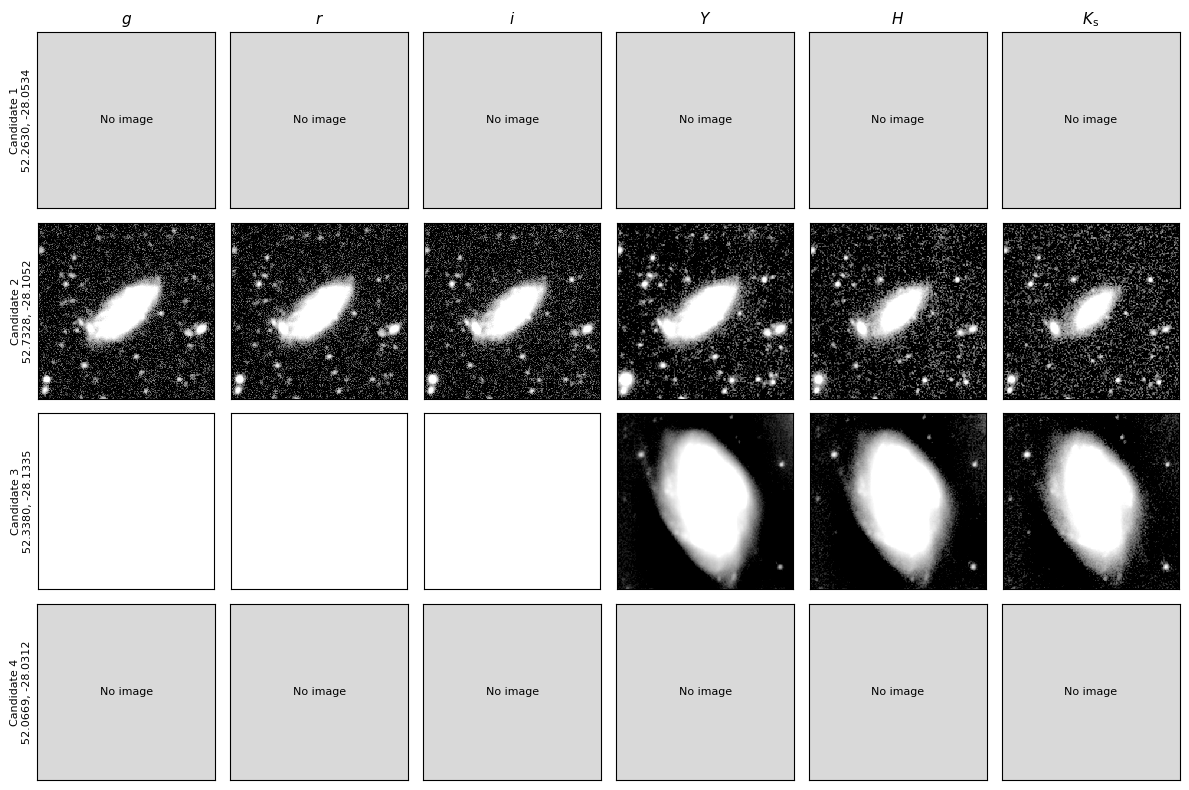

In [2]:
# ============================================================
# Optical--NIR morphology inspection of four galaxies
# ============================================================

from astropy.visualization import (
    ImageNormalize,
    AsinhStretch,
)


# ============================================================
# Repositories and bands
# ============================================================

COMCAM_DATASET_TYPE = "deep_coadd"

VIRCAM_REPO = "lsst-ir-fusion-dp1"
VIRCAM_DATASET_TYPE = "deepCoadd_calexp"

VIRCAM_PREFERRED_RUN = (
    "u/ir-sare1/DRP/videoCoaddDetect/"
    "20260405T092826Z"
)


COMCAM_MORPH_BANDS = [
    "g",
    "r",
    "i",
]

VIRCAM_MORPH_BANDS = [
    "Y",
    "H",
    "K",
]

MORPH_BANDS = (
    COMCAM_MORPH_BANDS
    + VIRCAM_MORPH_BANDS
)


PANEL_LABELS = {
    "g": r"$g$",
    "r": r"$r$",
    "i": r"$i$",
    "Y": r"$Y$",
    "H": r"$H$",
    "K": r"$K_{\rm s}$",
}


# ============================================================
# VIRCAM Butler
# ============================================================

butler_vista = Butler.from_config(
    VIRCAM_REPO
)

registry_vista = (
    butler_vista.registry
)


# ============================================================
# Visually selected galaxies
# ============================================================

visual_candidates = pd.DataFrame(
    [
        {
            "candidate": 1,
            "ra_deg": 52.2630355,
            "dec_deg": -28.0533876,
        },
        {
            "candidate": 2,
            "ra_deg": 52.7327587,
            "dec_deg": -28.1052238,
        },
        {
            "candidate": 3,
            "ra_deg": 52.3379854,
            "dec_deg": -28.1335329,
        },
        {
            "candidate": 4,
            "ra_deg": 52.0669085,
            "dec_deg": -28.0312429,
        },
    ]
)


display(
    visual_candidates
)


# ============================================================
# Cutout settings
# ============================================================

PIXEL_SCALE_ARCSEC = 0.2

# 300 pixels = 60 arcsec
CUTOUT_SIZE_PIX = 300


# ============================================================
# Helpers
# ============================================================

def make_cutout_bbox(
    exposure,
    sky_position,
    size_pix,
):

    centre = geom.Point2I(
        exposure
        .getWcs()
        .skyToPixel(
            sky_position
        )
    )

    extent = geom.Extent2I(
        size_pix,
        size_pix,
    )

    minimum = (
        centre
        - extent // 2
    )

    bbox = geom.Box2I(
        minimum,
        extent,
    )

    if not exposure.getBBox().contains(
        bbox
    ):

        raise ValueError(
            "Requested cutout is not fully "
            "contained in exposure."
        )

    return bbox


def extract_cutout(
    exposure,
    sky_position,
    size_pix,
):

    bbox = make_cutout_bbox(
        exposure,
        sky_position,
        size_pix,
    )

    cutout = exposure.getCutout(
        bbox
    )

    array = np.asarray(
        cutout.image.array,
        dtype=float,
    ).copy()

    mask_dict = (
        cutout.mask
        .getMaskPlaneDict()
    )

    if "NO_DATA" in mask_dict:

        bit = mask_dict["NO_DATA"]

        no_data = (
            np.asarray(
                cutout.mask.array,
                dtype=np.int64,
            )
            & (1 << bit)
        ) != 0

        array[no_data] = np.nan

    array[
        ~np.isfinite(array)
    ] = np.nan

    return array


def load_morphology_band(
    ra_deg,
    dec_deg,
    band,
):

    sky_position = geom.SpherePoint(
        ra_deg * geom.degrees,
        dec_deg * geom.degrees,
    )

    tract_info = skymap.findTract(
        sky_position
    )

    patch_info = tract_info.findPatch(
        sky_position
    )

    tract = tract_info.getId()

    patch = (
        patch_info
        .getSequentialIndex()
    )

    data_id = {
        "skymap": SKYMAP,
        "tract": tract,
        "patch": patch,
    }


    # --------------------------------------------------------
    # ComCam
    # --------------------------------------------------------

    if band in COMCAM_MORPH_BANDS:

        refs = list(
            set(
                butler.query_datasets(
                    COMCAM_DATASET_TYPE,
                    tract=tract,
                    patch=patch,
                    where=f"band = '{band}'",
                )
            )
        )

        if len(refs) == 0:

            raise RuntimeError(
                f"No ComCam {band} coadd"
            )

        exposure = butler.get(
            refs[0]
        )


    # --------------------------------------------------------
    # VIRCAM
    # --------------------------------------------------------

    else:

        refs = list(
            set(
                registry_vista.queryDatasets(
                    VIRCAM_DATASET_TYPE,
                    dataId=data_id,
                    collections=[
                        VIRCAM_PREFERRED_RUN
                    ],
                )
            )
        )

        refs = [
            ref
            for ref in refs
            if str(
                ref.dataId["band"]
            ) == band
        ]

        if len(refs) == 0:

            raise RuntimeError(
                f"No VIRCAM {band} coadd"
            )

        exposure = butler_vista.get(
            refs[0]
        )


    return extract_cutout(
        exposure,
        sky_position,
        CUTOUT_SIZE_PIX,
    )


# ============================================================
# Display normalization
# ============================================================

def morphology_display_norm(
    array,
):

    finite = np.asarray(
        array,
        dtype=float,
    )

    finite = finite[
        np.isfinite(finite)
    ]

    if finite.size == 0:

        return None


    median = np.median(
        finite
    )

    mad = np.median(
        np.abs(
            finite - median
        )
    )

    sigma = (
        1.4826 * mad
    )

    if (
        not np.isfinite(sigma)
        or sigma <= 0
    ):

        sigma = np.std(
            finite
        )


    vmin = (
        median
        - 0.1 * sigma
    )

    vmax = (
        median
        + 12.0 * sigma
    )


    return ImageNormalize(
        vmin=vmin,
        vmax=vmax,
        stretch=AsinhStretch(
            a=0.05
        ),
        clip=True,
    )


# ============================================================
# Load all cutouts
# ============================================================

candidate_images = {}


for _, row in (
    visual_candidates.iterrows()
):

    candidate_id = int(
        row["candidate"]
    )

    candidate_images[
        candidate_id
    ] = {}


    print(
        f"\nCandidate {candidate_id}: "
        f"{row['ra_deg']:.7f}, "
        f"{row['dec_deg']:.7f}"
    )


    for band in MORPH_BANDS:

        try:

            array = load_morphology_band(
                row["ra_deg"],
                row["dec_deg"],
                band,
            )

            candidate_images[
                candidate_id
            ][band] = array

            print(
                f"  {band}: "
                f"{array.shape}"
            )

        except Exception as exc:

            candidate_images[
                candidate_id
            ][band] = None

            print(
                f"  {band}: FAILED -- "
                f"{exc}"
            )


# ============================================================
# Plot
# ============================================================

n_candidates = len(
    visual_candidates
)

fig, axes = plt.subplots(
    n_candidates,
    len(MORPH_BANDS),
    figsize=(12, 8),
)


for row_index, row in (
    visual_candidates.iterrows()
):

    candidate_id = int(
        row["candidate"]
    )


    for band_index, band in enumerate(
        MORPH_BANDS
    ):

        ax = axes[
            row_index,
            band_index,
        ]

        array = candidate_images[
            candidate_id
        ][band]


        ax.set_xticks([])
        ax.set_yticks([])


        if array is None:

            ax.set_facecolor(
                "0.85"
            )

            ax.text(
                0.5,
                0.5,
                "No image",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=8,
            )

        else:

            norm = (
                morphology_display_norm(
                    array
                )
            )

            ax.imshow(
                array,
                origin="lower",
                cmap="gray",
                norm=norm,
                interpolation="none",
            )


        # Band labels
        if row_index == 0:

            ax.set_title(
                PANEL_LABELS[band],
                fontsize=11,
            )


        # Candidate labels
        if band_index == 0:

            ax.set_ylabel(
                (
                    f"Candidate "
                    f"{candidate_id}\n"
                    f"{row['ra_deg']:.4f}, "
                    f"{row['dec_deg']:.4f}"
                ),
                fontsize=8,
            )


plt.tight_layout()
plt.show()


### 2. Check image coverage of the first examples

Not every visually selected position lies within the usable ComCam--VIRCAM overlap. For the examples that can be retrieved in both datasets, we inspect the fraction of finite pixels in each band before interpreting their morphology.

This step separates genuine multi-band coverage from cases where a dataset exists for the patch but the requested position falls outside the valid image area.


In [3]:
# ============================================================
# Check finite-pixel coverage for candidates 2 and 3
# ============================================================

for candidate_id in [
    2,
    3,
]:

    print(
        f"\nCandidate {candidate_id}"
    )

    for band in MORPH_BANDS:

        array = (
            candidate_images[
                candidate_id
            ][band]
        )

        if array is None:

            print(
                f"  {band}: no image"
            )

            continue


        finite = np.isfinite(
            array
        )

        n_finite = np.sum(
            finite
        )

        fraction = (
            n_finite
            / array.size
        )


        if n_finite == 0:

            print(
                f"  {band}: "
                "0 finite pixels"
            )

            continue


        values = array[
            finite
        ]


        print(
            f"  {band}: "
            f"finite={fraction:.3f}, "
            f"min={np.min(values):.4g}, "
            f"median={np.median(values):.4g}, "
            f"max={np.max(values):.4g}"
        )



Candidate 2
  g: finite=1.000, min=-5.014, median=0.3998, max=657.1
  r: finite=1.000, min=-7.591, median=0.6054, max=1328
  i: finite=1.000, min=-13.82, median=0.8521, max=2066
  Y: finite=1.000, min=-2.426, median=0.1846, max=792.5
  H: finite=1.000, min=-8.63, median=0.4498, max=1306
  K: finite=1.000, min=-11.73, median=0.5033, max=1343

Candidate 3
  g: 0 finite pixels
  r: 0 finite pixels
  i: 0 finite pixels
  Y: finite=1.000, min=-11.46, median=0.02056, max=7974
  H: finite=1.000, min=-17.26, median=0.2617, max=1.411e+04
  K: finite=1.000, min=-19.57, median=0.6883, max=1.534e+04


### 3. Detailed morphology of one visually selected example

One of the visually inspected galaxies has complete usable ComCam $gri$ and VIRCAM $YHK_{\rm s}$ coverage within the fusion footprint. We examine this source in more detail as an early test of the optical--NIR comparison.

The initial six-band display suggests that the optical emission is more extended and structurally complex, while the near-infrared emission appears smoother and more centrally concentrated. A larger dynamic range is therefore used to preserve both the bright central region and lower-surface-brightness outer structure.


g: (240, 240)
r: (240, 240)
i: (240, 240)
Y: (240, 240)
H: (240, 240)
K: (240, 240)


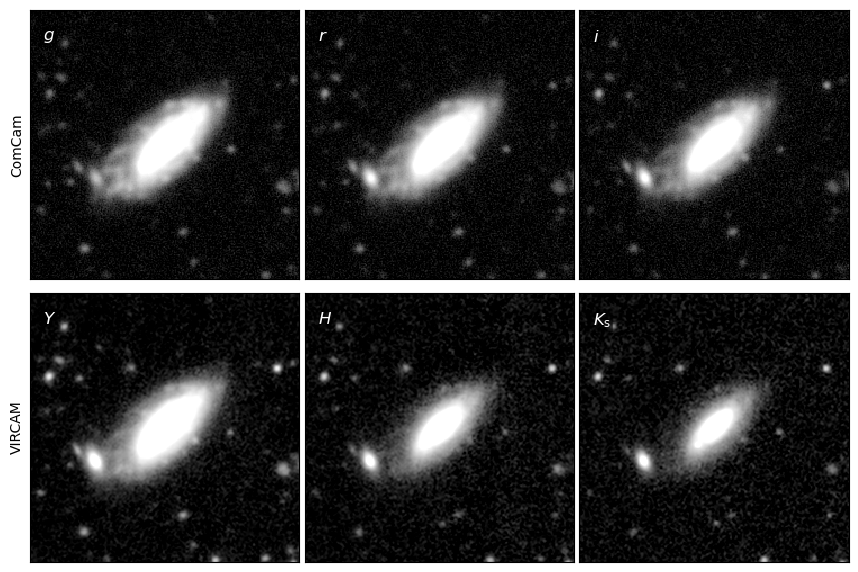

In [4]:
# ============================================================
# Detailed morphology figure for the selected galaxy
# ============================================================

FOCUS_RA = 52.7327587
FOCUS_DEC = -28.1052238

FOCUS_BANDS = [
    "g",
    "r",
    "i",
    "Y",
    "H",
    "K",
]

# 240 pixels = 48 arcsec
CUTOUT_SIZE_PIX = 240


# ============================================================
# Display normalization with larger dynamic range
# ============================================================

def detailed_morphology_norm(array):

    finite = np.asarray(
        array,
        dtype=float,
    )

    finite = finite[
        np.isfinite(finite)
    ]

    if finite.size == 0:
        return None


    median = np.median(
        finite
    )

    mad = np.median(
        np.abs(
            finite - median
        )
    )

    sigma = 1.4826 * mad

    if (
        not np.isfinite(sigma)
        or sigma <= 0
    ):

        sigma = np.std(
            finite
        )


    # Preserve faint outer structure.
    vmin = (
        median
        - 0.5 * sigma
    )

    # Larger range than the previous 12-sigma display,
    # so the central galaxy structure is less saturated.
    vmax = (
        median
        + 50.0 * sigma
    )


    return ImageNormalize(
        vmin=vmin,
        vmax=vmax,
        stretch=AsinhStretch(
            a=0.08
        ),
        clip=True,
    )


# ============================================================
# Load cutouts
# ============================================================

focus_images = {}


for band in FOCUS_BANDS:

    try:

        focus_images[band] = (
            load_morphology_band(
                FOCUS_RA,
                FOCUS_DEC,
                band,
            )
        )

        print(
            f"{band}: "
            f"{focus_images[band].shape}"
        )

    except Exception as exc:

        focus_images[band] = None

        print(
            f"{band}: FAILED -- {exc}"
        )


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(8.5, 5.8),
)

axes = axes.ravel()


for ax, band in zip(
    axes,
    FOCUS_BANDS,
):

    array = focus_images[
        band
    ]

    ax.set_xticks([])
    ax.set_yticks([])


    if array is None:

        ax.set_facecolor(
            "0.85"
        )

        ax.text(
            0.5,
            0.5,
            "No image",
            transform=ax.transAxes,
            ha="center",
            va="center",
        )

        continue


    norm = detailed_morphology_norm(
        array
    )


    ax.imshow(
        array,
        origin="lower",
        cmap="gray",
        norm=norm,
        interpolation="none",
    )


    ax.text(
        0.05,
        0.93,
        PANEL_LABELS[band],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        color="white",
        bbox=dict(
            facecolor="black",
            alpha=0.45,
            edgecolor="none",
            pad=1.5,
        ),
    )


# ------------------------------------------------------------
# Instrument labels
# ------------------------------------------------------------

axes[0].set_ylabel(
    "ComCam",
    fontsize=10,
)

axes[3].set_ylabel(
    "VIRCAM",
    fontsize=10,
)


plt.tight_layout(
    pad=0.4
)

plt.show()


### 4. Check the local PSF before interpreting morphology

A change in apparent concentration across wavelength can be produced partly by differences in image resolution. We therefore measure the local PSF in representative optical and NIR bands before interpreting the visual morphology of this example.


i: PSF shape=(35, 35), FWHM≈0.995 arcsec
K: PSF shape=(43, 43), FWHM≈0.825 arcsec


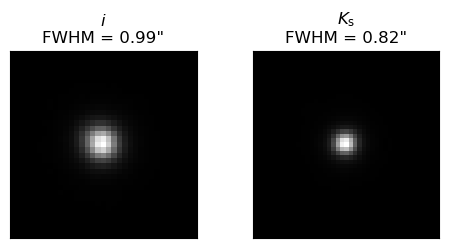

In [5]:
# ============================================================
# Local PSF at the selected galaxy position: i and Ks
# ============================================================

sky_position = geom.SpherePoint(
    FOCUS_RA * geom.degrees,
    FOCUS_DEC * geom.degrees,
)

tract_info = skymap.findTract(
    sky_position
)

patch_info = tract_info.findPatch(
    sky_position
)

tract = tract_info.getId()

patch = (
    patch_info
    .getSequentialIndex()
)


# ============================================================
# ComCam i exposure
# ============================================================

refs_i = list(
    set(
        butler.query_datasets(
            COMCAM_DATASET_TYPE,
            tract=tract,
            patch=patch,
            where="band = 'i'",
        )
    )
)

exp_i = butler.get(
    refs_i[0]
)


# ============================================================
# VIRCAM Ks exposure
# ============================================================

data_id = {
    "skymap": SKYMAP,
    "tract": tract,
    "patch": patch,
}

refs_k = list(
    set(
        registry_vista.queryDatasets(
            VIRCAM_DATASET_TYPE,
            dataId=data_id,
            collections=[
                VIRCAM_PREFERRED_RUN
            ],
        )
    )
)

refs_k = [
    ref
    for ref in refs_k
    if str(ref.dataId["band"]) == "K"
]

exp_k = butler_vista.get(
    refs_k[0]
)


# ============================================================
# Extract PSFs and estimate Gaussian-equivalent FWHM
# ============================================================

psf_results = {}


for band, exposure in [
    ("i", exp_i),
    ("K", exp_k),
]:

    position = (
        exposure
        .getWcs()
        .skyToPixel(
            sky_position
        )
    )

    psf = exposure.getPsf()

    psf_image = (
        psf.computeImage(
            position
        )
        .array
        .astype(float)
    )

    psf_image /= np.sum(
        psf_image
    )


    shape = psf.computeShape(
        position
    )

    sigma_pix = (
        shape.getDeterminantRadius()
    )

    pixel_scale = (
        exposure
        .getWcs()
        .getPixelScale()
        .asArcseconds()
    )

    fwhm_arcsec = (
        2.355
        * sigma_pix
        * pixel_scale
    )


    psf_results[band] = {
        "image": psf_image,
        "fwhm": fwhm_arcsec,
    }


    print(
        f"{band}: "
        f"PSF shape={psf_image.shape}, "
        f"FWHM≈{fwhm_arcsec:.3f} arcsec"
    )


# ============================================================
# Display
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(5, 2.5),
)


for ax, band in zip(
    axes,
    ["i", "K"],
):

    image = psf_results[
        band
    ]["image"]

    ax.imshow(
        image,
        origin="lower",
        cmap="gray",
    )

    ax.set_title(
        (
            f"{PANEL_LABELS[band]}\n"
            f"FWHM = "
            f"{psf_results[band]['fwhm']:.2f}\""
        )
    )

    ax.set_xticks([])
    ax.set_yticks([])


plt.tight_layout()
plt.show()


### 5. PSF-matched test for the first example

The VIRCAM $K_{\rm s}$ image has slightly better native resolution than the ComCam $i$ image at this position. To test whether the apparent difference in galaxy concentration is driven by this resolution difference, the $K_{\rm s}$ image is smoothed to approximately match the $i$-band PSF and the morphology is compared again.


Matching kernel FWHM = 0.556 arcsec
Matching kernel sigma = 1.181 pixels


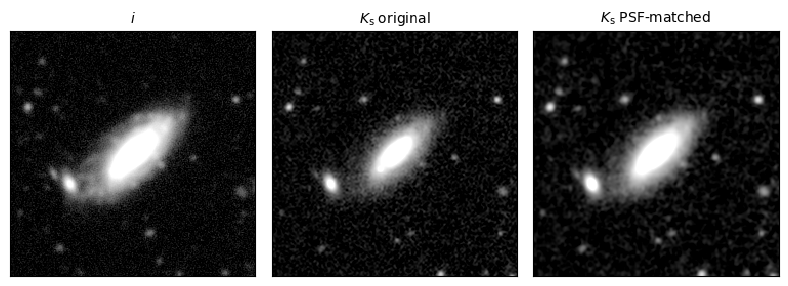

In [6]:
# ============================================================
# Match Ks approximately to the i-band PSF
# ============================================================

from scipy.ndimage import gaussian_filter


FWHM_I = psf_results["i"]["fwhm"]
FWHM_K = psf_results["K"]["fwhm"]

PIXEL_SCALE = 0.2


# Gaussian kernel required to broaden Ks to the i-band PSF
fwhm_kernel = np.sqrt(
    FWHM_I**2
    - FWHM_K**2
)

sigma_kernel_pix = (
    fwhm_kernel
    / 2.355
    / PIXEL_SCALE
)


print(
    f"Matching kernel FWHM = "
    f"{fwhm_kernel:.3f} arcsec"
)

print(
    f"Matching kernel sigma = "
    f"{sigma_kernel_pix:.3f} pixels"
)


# ------------------------------------------------------------
# Images already loaded in focus_images
# ------------------------------------------------------------

image_i = focus_images["i"]

image_k = focus_images["K"]


# Gaussian smoothing does not handle NaNs cleanly,
# so smooth image and valid-pixel weights separately.

valid_k = np.isfinite(
    image_k
)

data_k = np.where(
    valid_k,
    image_k,
    0.0,
)

weight_k = gaussian_filter(
    valid_k.astype(float),
    sigma_kernel_pix,
)

smooth_k = gaussian_filter(
    data_k,
    sigma_kernel_pix,
)


with np.errstate(
    invalid="ignore",
    divide="ignore",
):

    image_k_matched = (
        smooth_k
        / weight_k
    )


image_k_matched[
    weight_k <= 0
] = np.nan


# ============================================================
# Compare
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(8, 2.8),
)


comparison = [
    (
        image_i,
        r"$i$",
    ),
    (
        image_k,
        r"$K_{\rm s}$ original",
    ),
    (
        image_k_matched,
        r"$K_{\rm s}$ PSF-matched",
    ),
]


for ax, (
    image,
    title,
) in zip(
    axes,
    comparison,
):

    norm = detailed_morphology_norm(
        image
    )

    ax.imshow(
        image,
        origin="lower",
        cmap="gray",
        norm=norm,
        interpolation="none",
    )

    ax.set_title(
        title,
        fontsize=10,
    )

    ax.set_xticks([])
    ax.set_yticks([])


plt.tight_layout()
plt.show()


### 6. Inspect additional disk-galaxy candidates

The visual search also identified several galaxies with clearly resolved disks and central components. We check whether these positions have usable imaging in all six comparison bands, ComCam $gri$ and VIRCAM $YHK_{\rm s}$, before inspecting them further.

This preserves the exploratory visual-selection step used to find a particularly clear example for the paper.


In [7]:
# ============================================================
# Additional visually selected disk-galaxy candidates
# ============================================================

disk_candidates = pd.DataFrame(
    [
        [32, 53.0128644, -28.3582847],
        ["selected", 53.3450395, -28.1530860],
        [30, 53.3003275, -28.2108355],
        [29, 53.3291422, -28.2423702],
        [28, 51.8974566, -28.8094557],
        [27, 51.7401671, -29.0749868],
        [26, 51.8170589, -29.1615950],
        [25, 52.4008705, -29.2017583],
        [24, 52.4887104, -29.1879804],
        [23, 52.6821550, -29.1157483],
        [22, 52.7448035, -29.1437071],
        [21, 52.9457420, -29.1675353],
        [20, 52.9524520, -29.1118681],
        [19, 53.0249867, -29.1431901],
        [18, 53.0524207, -29.1525745],
        [17, 53.0881674, -29.1005443],
        [16, 53.1132080, -29.0194482],
        [15, 53.1796432, -28.2671822],
        [14, 51.9365065, -28.4883408],
        [13, 51.9655572, -28.6131361],
    ],
    columns=[
        "candidate",
        "ra_deg",
        "dec_deg",
    ],
)


# ============================================================
# Check usable gri + YHKs coverage
# ============================================================

coverage_rows = []


for _, row in disk_candidates.iterrows():

    candidate_id = row["candidate"]

    result = {
        "candidate": candidate_id,
        "ra_deg": row["ra_deg"],
        "dec_deg": row["dec_deg"],
    }

    display_label = (
        "Selected galaxy"
        if candidate_id == "selected"
        else f"Candidate {candidate_id}"
    )

    print(
        f"\n{display_label}: "
        f"{row['ra_deg']:.7f}, "
        f"{row['dec_deg']:.7f}"
    )

    all_good = True


    for band in MORPH_BANDS:

        try:

            array = load_morphology_band(
                row["ra_deg"],
                row["dec_deg"],
                band,
            )

            finite_fraction = np.mean(
                np.isfinite(array)
            )

        except Exception:

            finite_fraction = 0.0


        usable = (
            finite_fraction > 0.95
        )

        result[
            f"{band}_finite"
        ] = finite_fraction

        print(
            f"  {band}: "
            f"{finite_fraction:.3f}"
        )

        if not usable:
            all_good = False


    result[
        "all_six_good"
    ] = all_good

    coverage_rows.append(
        result
    )


# ============================================================
# Summary
# ============================================================

disk_coverage = pd.DataFrame(
    coverage_rows
)


print(
    "\nCandidates with usable "
    "gri + YHKs coverage:\n"
)


display(
    disk_coverage[
        disk_coverage[
            "all_six_good"
        ]
    ]
)



Candidate 32: 53.0128644, -28.3582847
  g: 1.000
  r: 1.000
  i: 1.000
  Y: 1.000
  H: 1.000
  K: 1.000

Selected galaxy: 53.3450395, -28.1530860
  g: 1.000
  r: 1.000
  i: 1.000
  Y: 1.000
  H: 1.000
  K: 1.000

Candidate 30: 53.3003275, -28.2108355
  g: 1.000
  r: 1.000
  i: 1.000
  Y: 1.000
  H: 1.000
  K: 1.000

Candidate 29: 53.3291422, -28.2423702
  g: 1.000
  r: 1.000
  i: 1.000
  Y: 1.000
  H: 1.000
  K: 1.000

Candidate 28: 51.8974566, -28.8094557
  g: 0.000
  r: 0.000
  i: 0.000
  Y: 0.000
  H: 0.000
  K: 0.000

Candidate 27: 51.7401671, -29.0749868
  g: 0.000
  r: 0.000
  i: 0.000
  Y: 0.000
  H: 0.000
  K: 0.000

Candidate 26: 51.8170589, -29.1615950
  g: 0.000
  r: 0.000
  i: 0.000
  Y: 0.000
  H: 0.000
  K: 0.000

Candidate 25: 52.4008705, -29.2017583
  g: 0.000
  r: 0.000
  i: 0.000
  Y: 0.000
  H: 0.000
  K: 0.000

Candidate 24: 52.4887104, -29.1879804
  g: 0.000
  r: 0.000
  i: 0.000
  Y: 0.000
  H: 0.000
  K: 0.000

Candidate 23: 52.6821550, -29.1157483
  g: 0.000
  

,candidate,ra_deg,dec_deg,g_finite,r_finite,i_finite,Y_finite,H_finite,K_finite,all_six_good
0,32,53.012864,-28.358285,1.0,1.0,1.0,1.0,1.0,1.0,True
1,selected,53.345039,-28.153086,1.0,1.0,1.0,1.0,1.0,1.0,True
2,30,53.300328,-28.210836,1.0,1.0,1.0,1.0,1.0,1.0,True
3,29,53.329142,-28.242370,1.0,1.0,1.0,1.0,1.0,1.0,True
17,15,53.179643,-28.267182,1.0,1.0,1.0,1.0,1.0,1.0,True


### 7. Inspect another visually selected disk galaxy

One of the additional disk galaxies has complete usable ComCam $gri$ and VIRCAM $YHK_{\rm s}$ coverage. Its VIDEO morphology shows a resolved inclined disk with a bright central component, making it useful for testing how the relative prominence of the disk and central emission changes across wavelength.


g: (240, 240)
r: (240, 240)
i: (240, 240)
Y: (240, 240)
H: (240, 240)
K: (240, 240)


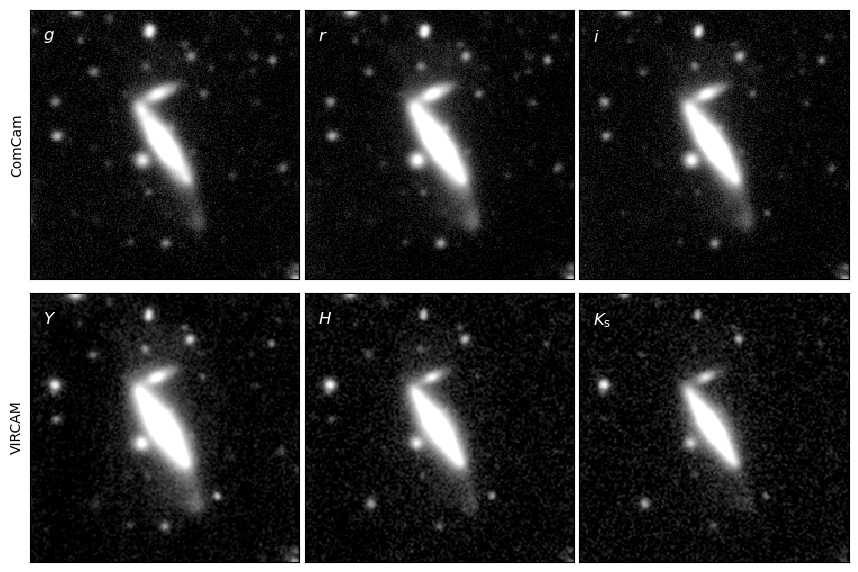

In [8]:
# ============================================================
# Detailed optical--NIR morphology of candidate 15
# ============================================================

CANDIDATE15_RA = 53.1796432
CANDIDATE15_DEC = -28.2671822

CANDIDATE15_BANDS = [
    "g",
    "r",
    "i",
    "Y",
    "H",
    "K",
]


# Same 48-arcsec field used for the previous candidate.
CUTOUT_SIZE_PIX = 240


# ============================================================
# Load images
# ============================================================

candidate15_images = {}


for band in CANDIDATE15_BANDS:

    try:

        array = load_morphology_band(
            CANDIDATE15_RA,
            CANDIDATE15_DEC,
            band,
        )

        candidate15_images[
            band
        ] = array

        print(
            f"{band}: {array.shape}"
        )

    except Exception as exc:

        candidate15_images[
            band
        ] = None

        print(
            f"{band}: FAILED -- {exc}"
        )


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(8.5, 5.8),
)

axes = axes.ravel()


for ax, band in zip(
    axes,
    CANDIDATE15_BANDS,
):

    array = candidate15_images[
        band
    ]

    ax.set_xticks([])
    ax.set_yticks([])


    if array is None:

        ax.set_facecolor(
            "0.85"
        )

        ax.text(
            0.5,
            0.5,
            "No image",
            transform=ax.transAxes,
            ha="center",
            va="center",
        )

        continue


    norm = detailed_morphology_norm(
        array
    )


    ax.imshow(
        array,
        origin="lower",
        cmap="gray",
        norm=norm,
        interpolation="none",
    )


    ax.text(
        0.05,
        0.93,
        PANEL_LABELS[band],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        color="white",
        bbox=dict(
            facecolor="black",
            alpha=0.45,
            edgecolor="none",
            pad=1.5,
        ),
    )


axes[0].set_ylabel(
    "ComCam",
    fontsize=10,
)

axes[3].set_ylabel(
    "VIRCAM",
    fontsize=10,
)


plt.tight_layout(
    pad=0.4
)

plt.show()


### 8. High-contrast display for morphology inspection

To make the disk, central component, and lower-surface-brightness structure easier to compare, we also inspect the six-band cutouts using a higher-contrast colour stretch. This display is used only for visual assessment and is not the final paper-style presentation.


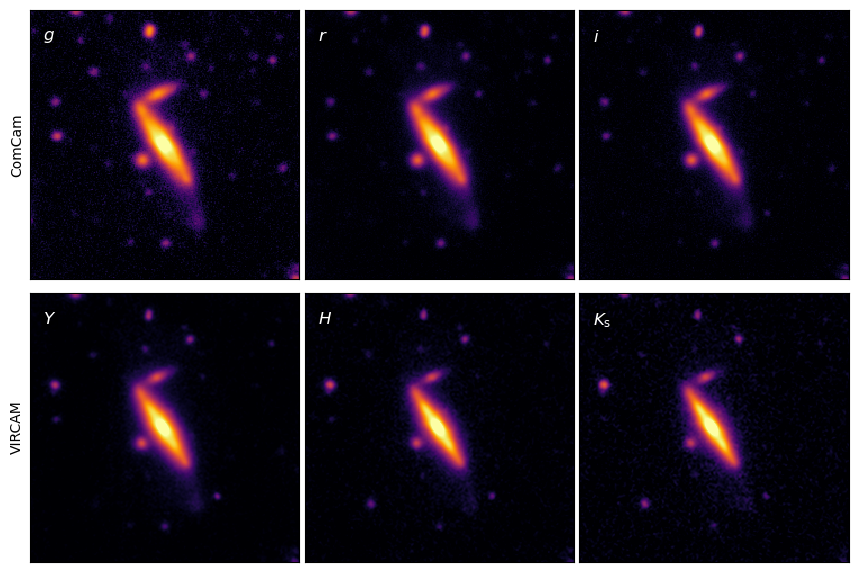

In [9]:
# ============================================================
# High-contrast colour display for candidate 15
# ============================================================

def high_contrast_norm(array):

    finite = np.asarray(
        array,
        dtype=float,
    )

    finite = finite[
        np.isfinite(finite)
    ]

    if finite.size == 0:
        return None


    median = np.median(
        finite
    )

    mad = np.median(
        np.abs(
            finite - median
        )
    )

    sigma = 1.4826 * mad

    if (
        not np.isfinite(sigma)
        or sigma <= 0
    ):
        sigma = np.std(
            finite
        )


    # More aggressive stretch for morphology.
    vmin = median - 0.3 * sigma
    vmax = np.percentile(
        finite,
        99.8,
    )

    if (
        not np.isfinite(vmax)
        or vmax <= vmin
    ):
        vmax = median + 40.0 * sigma


    return ImageNormalize(
        vmin=vmin,
        vmax=vmax,
        stretch=AsinhStretch(
            a=0.03
        ),
        clip=True,
    )


fig, axes = plt.subplots(
    2,
    3,
    figsize=(8.5, 5.8),
)

axes = axes.ravel()

for ax, band in zip(
    axes,
    CANDIDATE15_BANDS,
):

    array = candidate15_images[
        band
    ]

    ax.set_xticks([])
    ax.set_yticks([])

    if array is None:

        ax.set_facecolor("0.85")

        ax.text(
            0.5,
            0.5,
            "No image",
            transform=ax.transAxes,
            ha="center",
            va="center",
        )
        continue


    norm = high_contrast_norm(
        array
    )

    ax.imshow(
        array,
        origin="lower",
        cmap="inferno",
        norm=norm,
        interpolation="none",
    )

    ax.text(
        0.05,
        0.93,
        PANEL_LABELS[band],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        color="white",
        bbox=dict(
            facecolor="black",
            alpha=0.45,
            edgecolor="none",
            pad=1.5,
        ),
    )


axes[0].set_ylabel(
    "ComCam",
    fontsize=10,
)

axes[3].set_ylabel(
    "VIRCAM",
    fontsize=10,
)

plt.tight_layout(
    pad=0.4
)
plt.show()


### 9. Reusable display for comparing visual candidates

A reusable plotting helper is defined so that several visually selected galaxies can be compared using the same ComCam $gri$ and VIRCAM $YHK_{\rm s}$ layout and the same high-contrast display procedure.


In [10]:
# ============================================================
# Reusable colour plot for a single candidate
# ============================================================

DISPLAY_BANDS = ["g", "r", "i", "Y", "H", "K"]


def plot_candidate_colour(
    ra_deg,
    dec_deg,
    bands=DISPLAY_BANDS,
    candidate_label=None,
    cmap="inferno",
):

    images = {}

    for band in bands:
        try:
            images[band] = load_morphology_band(
                ra_deg,
                dec_deg,
                band,
            )
            print(f"{band}: {images[band].shape}")
        except Exception as exc:
            images[band] = None
            print(f"{band}: FAILED -- {exc}")

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(8.5, 5.8),
    )

    axes = axes.ravel()

    for ax, band in zip(axes, bands):

        array = images[band]

        ax.set_xticks([])
        ax.set_yticks([])

        if array is None:
            ax.set_facecolor("0.85")
            ax.text(
                0.5,
                0.5,
                "No image",
                transform=ax.transAxes,
                ha="center",
                va="center",
            )
            continue

        norm = high_contrast_norm(array)

        ax.imshow(
            array,
            origin="lower",
            cmap=cmap,
            norm=norm,
            interpolation="none",
        )

        ax.text(
            0.05,
            0.93,
            PANEL_LABELS[band],
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=12,
            color="white",
            bbox=dict(
                facecolor="black",
                alpha=0.45,
                edgecolor="none",
                pad=1.5,
            ),
        )

    axes[0].set_ylabel("ComCam", fontsize=10)
    axes[3].set_ylabel("VIRCAM", fontsize=10)

    if candidate_label is not None:
        fig.suptitle(
            candidate_label,
            y=0.98,
            fontsize=12,
        )

    plt.tight_layout(
        pad=0.5
    )
    plt.show()


### 10. Compare representative visual examples and choose the final object

The reusable display is applied to several of the visually selected galaxies. These intermediate examples are kept here to show the actual inspection process rather than presenting the final object without context.

The final selected galaxy is the object at RA = 53.3450395 deg and Dec = -28.1530860 deg. From this point onward it is referred to simply as the **selected galaxy**.


g: (240, 240)
r: (240, 240)
i: (240, 240)
Y: (240, 240)
H: (240, 240)
K: (240, 240)


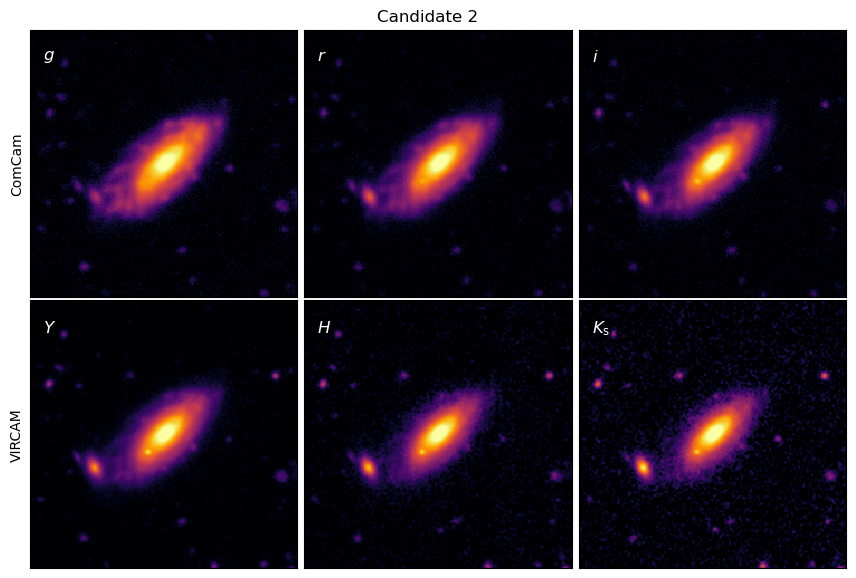

In [11]:
# ============================================================
# Candidate 2 in colour
# ============================================================

plot_candidate_colour(
    ra_deg=52.7327587,
    dec_deg=-28.1052238,
    candidate_label="Candidate 2",
    cmap="inferno",
)


g: (240, 240)
r: (240, 240)
i: (240, 240)
Y: (240, 240)
H: (240, 240)
K: (240, 240)


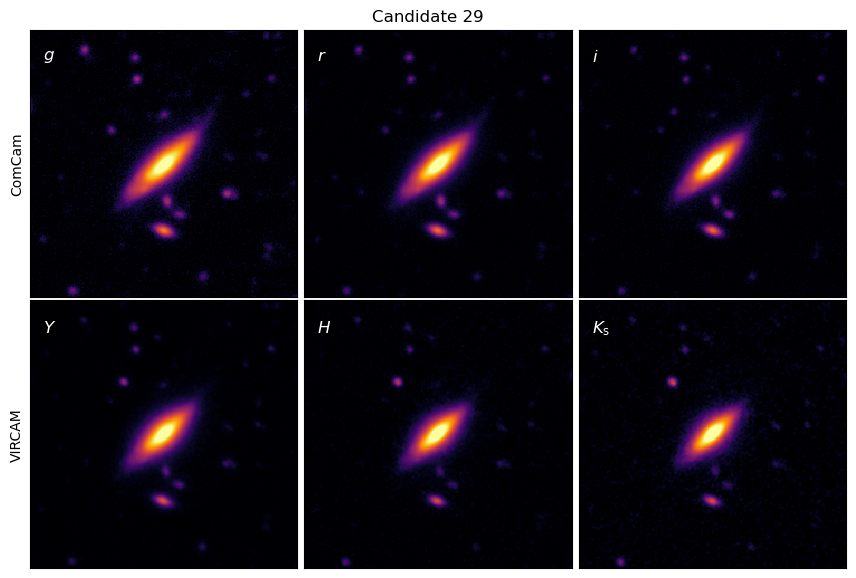

In [12]:
# ============================================================
# Candidate 29
# ============================================================

plot_candidate_colour(
    ra_deg=53.3291422,
    dec_deg=-28.2423702,
    candidate_label="Candidate 29",
    cmap="inferno",
)


g: (240, 240)
r: (240, 240)
i: (240, 240)
Y: (240, 240)
H: (240, 240)
K: (240, 240)


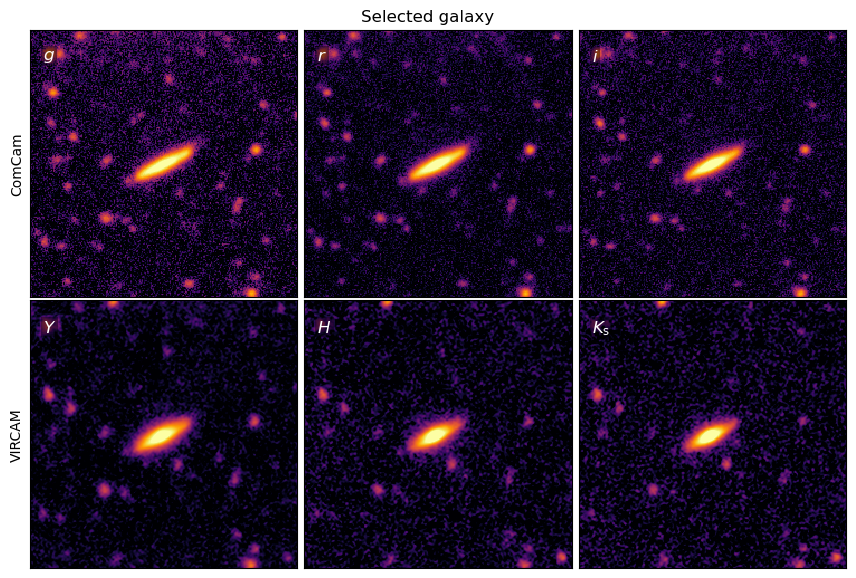

In [13]:
# ============================================================
# Selected galaxy
# ============================================================

plot_candidate_colour(
    ra_deg=53.3450395,
    dec_deg=-28.1530860,
    candidate_label="Selected galaxy",
    cmap="inferno",
)


### 11. PSF comparison for the selected galaxy

After comparing the visually selected examples, the galaxy at RA = 53.3450395 deg and Dec = -28.1530860 deg was chosen for the final paper illustration because it has clear resolved structure and complete optical--NIR coverage.

Its optical images show an extended thin disk, while the central component becomes relatively more prominent toward the NIR. Before using this wavelength-dependent morphology, we measure the local PSF across the six test bands to check whether the trend could be produced by resolution differences.


In [14]:
# ============================================================
# Local PSF across gri + YHKs for selected galaxy
# ============================================================

SELECTED_GALAXY_RA = 53.3450395
SELECTED_GALAXY_DEC = -28.1530860

PSF_BANDS = [
    "g",
    "r",
    "i",
    "Y",
    "H",
    "K",
]


sky_position = geom.SpherePoint(
    SELECTED_GALAXY_RA * geom.degrees,
    SELECTED_GALAXY_DEC * geom.degrees,
)


# ============================================================
# Helper: retrieve exposure
# ============================================================

def get_morphology_exposure(
    ra_deg,
    dec_deg,
    band,
):

    position = geom.SpherePoint(
        ra_deg * geom.degrees,
        dec_deg * geom.degrees,
    )

    tract_info = skymap.findTract(
        position
    )

    patch_info = tract_info.findPatch(
        position
    )

    tract = tract_info.getId()

    patch = (
        patch_info
        .getSequentialIndex()
    )


    # --------------------------------------------------------
    # ComCam
    # --------------------------------------------------------

    if band in COMCAM_MORPH_BANDS:

        refs = list(
            set(
                butler.query_datasets(
                    COMCAM_DATASET_TYPE,
                    tract=tract,
                    patch=patch,
                    where=f"band = '{band}'",
                )
            )
        )

        if len(refs) == 0:
            raise RuntimeError(
                f"No ComCam {band} coadd"
            )

        return butler.get(
            refs[0]
        )


    # --------------------------------------------------------
    # VIRCAM
    # --------------------------------------------------------

    data_id = {
        "skymap": SKYMAP,
        "tract": tract,
        "patch": patch,
    }

    refs = list(
        set(
            registry_vista.queryDatasets(
                VIRCAM_DATASET_TYPE,
                dataId=data_id,
                collections=[
                    VIRCAM_PREFERRED_RUN
                ],
            )
        )
    )

    refs = [
        ref
        for ref in refs
        if str(
            ref.dataId["band"]
        ) == band
    ]

    if len(refs) == 0:
        raise RuntimeError(
            f"No VIRCAM {band} coadd"
        )

    return butler_vista.get(
        refs[0]
    )


# ============================================================
# Measure local PSF
# ============================================================

selected_psf_results = {}


for band in PSF_BANDS:

    exposure = get_morphology_exposure(
        SELECTED_GALAXY_RA,
        SELECTED_GALAXY_DEC,
        band,
    )

    pixel_position = (
        exposure
        .getWcs()
        .skyToPixel(
            sky_position
        )
    )

    psf = exposure.getPsf()

    psf_image = (
        psf.computeImage(
            pixel_position
        )
        .array
        .astype(float)
    )

    psf_image /= np.sum(
        psf_image
    )

    shape = psf.computeShape(
        pixel_position
    )

    sigma_pix = (
        shape.getDeterminantRadius()
    )

    pixel_scale = (
        exposure
        .getWcs()
        .getPixelScale()
        .asArcseconds()
    )

    fwhm_arcsec = (
        2.355
        * sigma_pix
        * pixel_scale
    )


    selected_psf_results[band] = {
        "image": psf_image,
        "fwhm": fwhm_arcsec,
        "pixel_scale": pixel_scale,
    }


    print(
        f"{band:>2s}: "
        f"FWHM = {fwhm_arcsec:.3f} arcsec, "
        f"pixel scale = {pixel_scale:.3f} arcsec/pix, "
        f"PSF shape = {psf_image.shape}"
    )


 g: FWHM = 1.106 arcsec, pixel scale = 0.200 arcsec/pix, PSF shape = (35, 35)
 r: FWHM = 1.047 arcsec, pixel scale = 0.200 arcsec/pix, PSF shape = (35, 35)
 i: FWHM = 0.959 arcsec, pixel scale = 0.200 arcsec/pix, PSF shape = (35, 35)
 Y: FWHM = 0.905 arcsec, pixel scale = 0.200 arcsec/pix, PSF shape = (43, 43)
 H: FWHM = 0.913 arcsec, pixel scale = 0.200 arcsec/pix, PSF shape = (43, 43)
 K: FWHM = 0.902 arcsec, pixel scale = 0.200 arcsec/pix, PSF shape = (43, 43)


### 12. PSF-matched morphology of the selected galaxy

The local PSF varies across the six bands, with the NIR images having slightly better native resolution than the broadest optical image. We therefore smooth all six images to a common target PSF and repeat the morphology comparison.

The purpose of this test is to verify that the increasing prominence of the central component toward the NIR is not simply an image-resolution effect.


 g: native=1.106", kernel=0.000", sigma=0.000 pix
 r: native=1.047", kernel=0.356", sigma=0.755 pix
 i: native=0.959", kernel=0.552", sigma=1.172 pix
 Y: native=0.905", kernel=0.636", sigma=1.350 pix
 H: native=0.913", kernel=0.624", sigma=1.325 pix
 K: native=0.902", kernel=0.640", sigma=1.358 pix


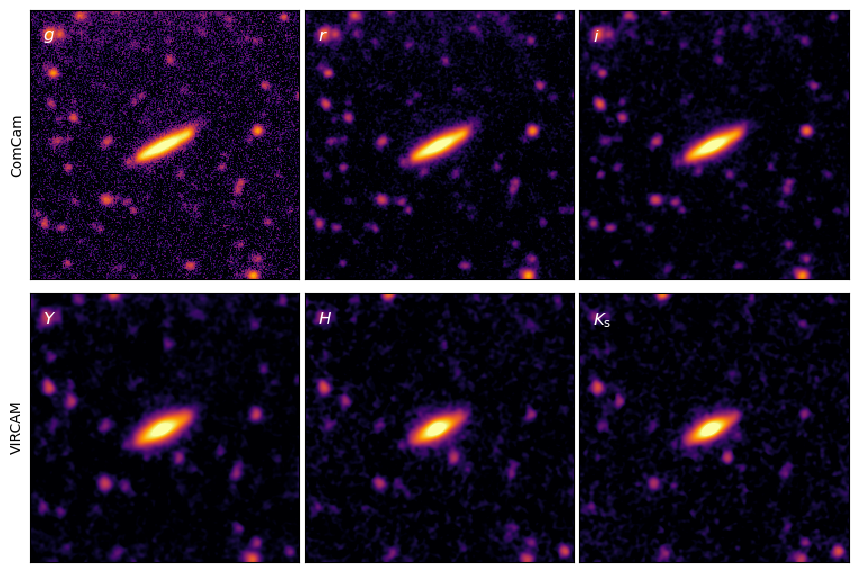

In [15]:
# ============================================================
# PSF-match all six bands to the g-band resolution
# ============================================================

from scipy.ndimage import gaussian_filter


TARGET_FWHM = selected_psf_results["g"]["fwhm"]

PSF_MATCH_BANDS = [
    "g",
    "r",
    "i",
    "Y",
    "H",
    "K",
]


# ============================================================
# Load selected galaxy images
# ============================================================

selected_galaxy_images = {}


for band in PSF_MATCH_BANDS:

    selected_galaxy_images[band] = (
        load_morphology_band(
            SELECTED_GALAXY_RA,
            SELECTED_GALAXY_DEC,
            band,
        )
    )


# ============================================================
# NaN-safe Gaussian smoothing
# ============================================================

def gaussian_smooth_nan(
    image,
    sigma_pix,
):

    if sigma_pix <= 0:
        return image.copy()

    valid = np.isfinite(
        image
    )

    data = np.where(
        valid,
        image,
        0.0,
    )

    smooth_data = gaussian_filter(
        data,
        sigma_pix,
    )

    smooth_weight = gaussian_filter(
        valid.astype(float),
        sigma_pix,
    )

    with np.errstate(
        invalid="ignore",
        divide="ignore",
    ):

        result = (
            smooth_data
            / smooth_weight
        )

    result[
        smooth_weight <= 0
    ] = np.nan

    return result


# ============================================================
# Match each band to g
# ============================================================

selected_galaxy_matched = {}


for band in PSF_MATCH_BANDS:

    native_fwhm = (
        selected_psf_results[
            band
        ]["fwhm"]
    )

    pixel_scale = (
        selected_psf_results[
            band
        ]["pixel_scale"]
    )


    if native_fwhm >= TARGET_FWHM:

        kernel_fwhm = 0.0
        sigma_pix = 0.0

    else:

        kernel_fwhm = np.sqrt(
            TARGET_FWHM**2
            - native_fwhm**2
        )

        sigma_pix = (
            kernel_fwhm
            / 2.355
            / pixel_scale
        )


    selected_galaxy_matched[
        band
    ] = gaussian_smooth_nan(
        selected_galaxy_images[
            band
        ],
        sigma_pix,
    )


    print(
        f"{band:>2s}: "
        f"native={native_fwhm:.3f}\", "
        f"kernel={kernel_fwhm:.3f}\", "
        f"sigma={sigma_pix:.3f} pix"
    )


# ============================================================
# Plot PSF-matched images
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(8.5, 5.8),
)

axes = axes.ravel()


for ax, band in zip(
    axes,
    PSF_MATCH_BANDS,
):

    image = selected_galaxy_matched[
        band
    ]

    norm = high_contrast_norm(
        image
    )

    ax.imshow(
        image,
        origin="lower",
        cmap="inferno",
        norm=norm,
        interpolation="none",
    )

    ax.text(
        0.05,
        0.93,
        PANEL_LABELS[band],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        color="white",
    )

    ax.set_xticks([])
    ax.set_yticks([])


axes[0].set_ylabel(
    "ComCam",
    fontsize=10,
)

axes[3].set_ylabel(
    "VIRCAM",
    fontsize=10,
)


plt.tight_layout(
    pad=0.4
)

plt.show()


### 13. Check full 11-band coverage of the selected galaxy

The wavelength-dependent morphology remains visible in the six-band PSF-matched test. We therefore extend the coverage check to the full Rubin ComCam $ugrizy$ and VIRCAM $ZYJHK_{\rm s}$ set required for the final multi-band figure.


In [16]:
# ============================================================
# Check full 11-band coverage for selected galaxy
# ============================================================

FULL_COMCAM_BANDS = [
    "u",
    "g",
    "r",
    "i",
    "z",
    "y",
]

FULL_VIRCAM_BANDS = [
    "Z",
    "Y",
    "J",
    "H",
    "K",
]

FULL_BANDS = (
    FULL_COMCAM_BANDS
    + FULL_VIRCAM_BANDS
)


def load_full_band(
    ra_deg,
    dec_deg,
    band,
):

    sky_position = geom.SpherePoint(
        ra_deg * geom.degrees,
        dec_deg * geom.degrees,
    )

    tract_info = skymap.findTract(
        sky_position
    )

    patch_info = tract_info.findPatch(
        sky_position
    )

    tract = tract_info.getId()

    patch = (
        patch_info
        .getSequentialIndex()
    )


    # --------------------------------------------------------
    # ComCam
    # --------------------------------------------------------

    if band in FULL_COMCAM_BANDS:

        refs = list(
            set(
                butler.query_datasets(
                    COMCAM_DATASET_TYPE,
                    tract=tract,
                    patch=patch,
                    where=f"band = '{band}'",
                )
            )
        )

        if len(refs) == 0:
            raise RuntimeError(
                f"No ComCam {band} coadd"
            )

        exposure = butler.get(
            refs[0]
        )


    # --------------------------------------------------------
    # VIRCAM
    # --------------------------------------------------------

    else:

        data_id = {
            "skymap": SKYMAP,
            "tract": tract,
            "patch": patch,
        }

        refs = list(
            set(
                registry_vista.queryDatasets(
                    VIRCAM_DATASET_TYPE,
                    dataId=data_id,
                    collections=[
                        VIRCAM_PREFERRED_RUN
                    ],
                )
            )
        )

        refs = [
            ref
            for ref in refs
            if str(
                ref.dataId["band"]
            ) == band
        ]

        if len(refs) == 0:
            raise RuntimeError(
                f"No VIRCAM {band} coadd"
            )

        exposure = butler_vista.get(
            refs[0]
        )


    return extract_cutout(
        exposure,
        sky_position,
        CUTOUT_SIZE_PIX,
    )


# ============================================================
# Coverage test
# ============================================================

selected_galaxy_full_images = {}


for band in FULL_BANDS:

    try:

        array = load_full_band(
            SELECTED_GALAXY_RA,
            SELECTED_GALAXY_DEC,
            band,
        )

        selected_galaxy_full_images[
            band
        ] = array

        finite_fraction = np.mean(
            np.isfinite(array)
        )

        print(
            f"{band:>2s}: "
            f"finite fraction = "
            f"{finite_fraction:.3f}"
        )

    except Exception as exc:

        selected_galaxy_full_images[
            band
        ] = None

        print(
            f"{band:>2s}: "
            f"FAILED -- {exc}"
        )


 u: finite fraction = 1.000
 g: finite fraction = 1.000
 r: finite fraction = 1.000
 i: finite fraction = 1.000
 z: finite fraction = 1.000
 y: finite fraction = 1.000
 Z: finite fraction = 1.000
 Y: finite fraction = 1.000
 J: finite fraction = 1.000
 H: finite fraction = 1.000
 K: finite fraction = 1.000


### 14. Measure the local PSF across all 11 bands

The selected galaxy has complete usable imaging in all six ComCam $ugrizy$ bands and all five VIRCAM $ZYJHK_{\rm s}$ bands. Before constructing the final morphology figure, we measure the local PSF at the galaxy position in every band to document the native image resolution.


In [17]:
# ============================================================
# Local PSF in all 11 bands for selected galaxy
# ============================================================

FULL_PSF_BANDS = [
    "u", "g", "r", "i", "z", "y",
    "Z", "Y", "J", "H", "K",
]


# ============================================================
# Retrieve exposure
# ============================================================

def get_full_exposure(
    ra_deg,
    dec_deg,
    band,
):

    sky_position = geom.SpherePoint(
        ra_deg * geom.degrees,
        dec_deg * geom.degrees,
    )

    tract_info = skymap.findTract(
        sky_position
    )

    patch_info = tract_info.findPatch(
        sky_position
    )

    tract = tract_info.getId()

    patch = (
        patch_info
        .getSequentialIndex()
    )


    # --------------------------------------------------------
    # ComCam
    # --------------------------------------------------------

    if band in FULL_COMCAM_BANDS:

        refs = list(
            set(
                butler.query_datasets(
                    COMCAM_DATASET_TYPE,
                    tract=tract,
                    patch=patch,
                    where=f"band = '{band}'",
                )
            )
        )

        if len(refs) == 0:
            raise RuntimeError(
                f"No ComCam {band} coadd"
            )

        return butler.get(
            refs[0]
        )


    # --------------------------------------------------------
    # VIRCAM
    # --------------------------------------------------------

    data_id = {
        "skymap": SKYMAP,
        "tract": tract,
        "patch": patch,
    }

    refs = list(
        set(
            registry_vista.queryDatasets(
                VIRCAM_DATASET_TYPE,
                dataId=data_id,
                collections=[
                    VIRCAM_PREFERRED_RUN
                ],
            )
        )
    )

    refs = [
        ref
        for ref in refs
        if str(
            ref.dataId["band"]
        ) == band
    ]

    if len(refs) == 0:
        raise RuntimeError(
            f"No VIRCAM {band} coadd"
        )

    return butler_vista.get(
        refs[0]
    )


# ============================================================
# Measure PSFs
# ============================================================

selected_galaxy_psf_full = {}


sky_position = geom.SpherePoint(
    SELECTED_GALAXY_RA * geom.degrees,
    SELECTED_GALAXY_DEC * geom.degrees,
)


for band in FULL_PSF_BANDS:

    exposure = get_full_exposure(
        SELECTED_GALAXY_RA,
        SELECTED_GALAXY_DEC,
        band,
    )

    pixel_position = (
        exposure
        .getWcs()
        .skyToPixel(
            sky_position
        )
    )

    psf = exposure.getPsf()

    psf_image = (
        psf.computeImage(
            pixel_position
        )
        .array
        .astype(float)
    )

    psf_image /= np.sum(
        psf_image
    )

    shape = psf.computeShape(
        pixel_position
    )

    sigma_pix = (
        shape.getDeterminantRadius()
    )

    pixel_scale = (
        exposure
        .getWcs()
        .getPixelScale()
        .asArcseconds()
    )

    fwhm_arcsec = (
        2.355
        * sigma_pix
        * pixel_scale
    )


    selected_galaxy_psf_full[
        band
    ] = {
        "image": psf_image,
        "fwhm": fwhm_arcsec,
        "pixel_scale": pixel_scale,
    }


    print(
        f"{band:>2s}: "
        f"FWHM = {fwhm_arcsec:.3f} arcsec, "
        f"PSF shape = {psf_image.shape}"
    )


# ============================================================
# Broadest PSF
# ============================================================

target_band = max(
    selected_galaxy_psf_full,
    key=lambda band:
        selected_galaxy_psf_full[
            band
        ]["fwhm"],
)

target_fwhm = (
    selected_galaxy_psf_full[
        target_band
    ]["fwhm"]
)


print(
    "\nBroadest PSF:"
)

print(
    f"{target_band}: "
    f"{target_fwhm:.3f} arcsec"
)


 u: FWHM = 1.346 arcsec, PSF shape = (35, 35)
 g: FWHM = 1.106 arcsec, PSF shape = (35, 35)
 r: FWHM = 1.047 arcsec, PSF shape = (35, 35)
 i: FWHM = 0.959 arcsec, PSF shape = (35, 35)
 z: FWHM = 0.996 arcsec, PSF shape = (35, 35)
 y: FWHM = 1.069 arcsec, PSF shape = (33, 33)
 Z: FWHM = 0.957 arcsec, PSF shape = (43, 43)
 Y: FWHM = 0.905 arcsec, PSF shape = (43, 43)
 J: FWHM = 0.894 arcsec, PSF shape = (43, 43)
 H: FWHM = 0.913 arcsec, PSF shape = (43, 43)
 K: FWHM = 0.902 arcsec, PSF shape = (43, 43)

Broadest PSF:
u: 1.346 arcsec


### 15. Paper figure: wavelength-dependent morphology of the selected galaxy

The final figure compares the selected galaxy across the available optical and near-infrared bands at native resolution. Each band is displayed with an independent stretch so that both the extended optical disk and the increasingly prominent NIR central component remain visible.

The preceding coverage and PSF checks provide the validation for using this object as the illustrative morphology example in the paper.


u (240, 240) 1.0
g (240, 240) 1.0
r (240, 240) 1.0
i (240, 240) 1.0
z (240, 240) 1.0
y (240, 240) 1.0
Z (240, 240) 1.0
Y (240, 240) 1.0
J (240, 240) 1.0
H (240, 240) 1.0
K (240, 240) 1.0


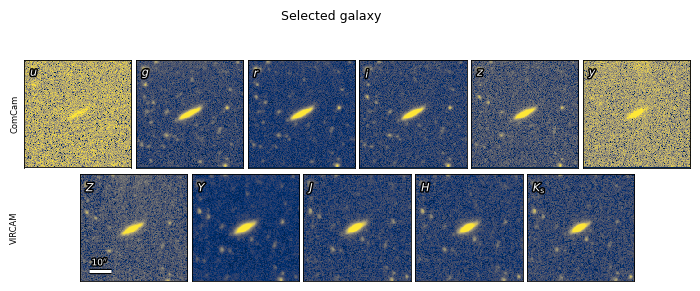

Saved PNG: selected_galaxy_11band_native_independent.png
Saved PDF: selected_galaxy_11band_native_independent.pdf
Used native-resolution cutouts with independent per-band asinh stretch.


In [18]:
# ------------------------------------------------------------
# Paper-style 11-band morphology figure for selected galaxy
# - native resolution
# - independent stretch in each band
# - same style as Fig. 8
# - no colorbar
# ------------------------------------------------------------

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from astropy.visualization import ImageNormalize, AsinhStretch

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
CMAP_NAME = "cividis"
PIXEL_SCALE_ARCSEC = 0.2
SCALE_BAR_ARCSEC = 10.0

COMCAM_BANDS = ["u", "g", "r", "i", "z", "y"]
VIRCAM_BANDS = ["Z", "Y", "J", "H", "K"]
ALL_BANDS = COMCAM_BANDS + VIRCAM_BANDS

PANEL_LABELS = {
    "u": r"$u$",
    "g": r"$g$",
    "r": r"$r$",
    "i": r"$i$",
    "z": r"$z$",
    "y": r"$y$",
    "Z": r"$Z$",
    "Y": r"$Y$",
    "J": r"$J$",
    "H": r"$H$",
    "K": r"$K_{\rm s}$",
}

# change if needed
FIG_TITLE = "Selected galaxy"
PNG_NAME = "selected_galaxy_11band_native_independent.png"
PDF_NAME = "selected_galaxy_11band_native_independent.pdf"


# ============================================================
# Use the already loaded native-resolution selected galaxy images
# ============================================================

cutout_arrays = {
    band: selected_galaxy_full_images[band]
    for band in ALL_BANDS
}

for band in ALL_BANDS:
    print(
        band,
        cutout_arrays[band].shape,
        np.mean(np.isfinite(cutout_arrays[band])),
    )
    
# ------------------------------------------------------------
# Robust display normalization (independent per band)
# ------------------------------------------------------------
def display_normalization(array):
    finite = array[np.isfinite(array)]
    if finite.size == 0:
        return ImageNormalize(vmin=0, vmax=1, stretch=AsinhStretch(0.1)), 0, 1

    med = np.median(finite)
    p99 = np.percentile(finite, 99.5)
    p01 = np.percentile(finite, 1.0)

    vmin = p01
    vmax = p99

    # safety
    if not np.isfinite(vmin):
        vmin = med - 1.0
    if not np.isfinite(vmax):
        vmax = med + 1.0
    if vmax <= vmin:
        vmax = vmin + 1.0e-6

    norm = ImageNormalize(
        vmin=vmin,
        vmax=vmax,
        stretch=AsinhStretch(0.1),
        clip=True,
    )

    return norm, vmin, vmax

# ------------------------------------------------------------
# Build one normalization per band
# Assumes cutout_arrays[band] already exists for selected galaxy
# ------------------------------------------------------------
norms = {}
for band in ALL_BANDS:
    norm, _, _ = display_normalization(cutout_arrays[band])
    norms[band] = norm

# ------------------------------------------------------------
# Manual compact layout, same spirit as Fig. 8
# ------------------------------------------------------------
fig_w = 7.4
fig_h = 3.1
fig = plt.figure(figsize=(fig_w, fig_h))

label_left = 0.072
panel_left = 0.085
panel_right = 0.985
panel_gap_x = 0.006

panel_w = (panel_right - panel_left - 5 * panel_gap_x) / 6.0
panel_h = panel_w * (fig_w / fig_h)

row_gap_y = 0.020
bottom_y = 0.11
top_y = bottom_y + panel_h + row_gap_y

bottom_left = panel_left + 0.5 * (panel_w + panel_gap_x)

axes = {}

# top row: ComCam
for i, band in enumerate(COMCAM_BANDS):
    x0 = panel_left + i * (panel_w + panel_gap_x)
    axes[band] = fig.add_axes([x0, top_y, panel_w, panel_h])

# bottom row: VIRCAM
for i, band in enumerate(VIRCAM_BANDS):
    x0 = bottom_left + i * (panel_w + panel_gap_x)
    axes[band] = fig.add_axes([x0, bottom_y, panel_w, panel_h])

# ------------------------------------------------------------
# Draw images
# ------------------------------------------------------------
for band in ALL_BANDS:
    ax = axes[band]
    image = cutout_arrays[band]

    ny, nx = image.shape

    ax.set_facecolor(plt.get_cmap(CMAP_NAME)(0.0))

    ax.imshow(
        image,
        origin="lower",
        cmap=CMAP_NAME,
        norm=norms[band],
        interpolation="none",
    )

    ax.set_xlim(-0.5, nx - 0.5)
    ax.set_ylim(-0.5, ny - 0.5)
    ax.set_aspect("equal", adjustable="box")

    ax.text(
        0.055,
        0.93,
        PANEL_LABELS[band],
        transform=ax.transAxes,
        ha="left",
        va="top",
        color="white",
        fontsize=8,
        path_effects=[
            pe.withStroke(linewidth=2.1, foreground="black")
        ],
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color("black")

# ------------------------------------------------------------
# Row labels
# ------------------------------------------------------------
fig.text(
    label_left,
    top_y + 0.5 * panel_h,
    "ComCam",
    rotation=90,
    ha="center",
    va="center",
    fontsize=6,
)

fig.text(
    label_left,
    bottom_y + 0.5 * panel_h,
    "VIRCAM",
    rotation=90,
    ha="center",
    va="center",
    fontsize=6,
)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------
fig.text(
    0.5,
    0.985,
    FIG_TITLE,
    ha="center",
    va="top",
    fontsize=9,
)

# ------------------------------------------------------------
# 10 arcsec scale bar on first VIRCAM panel (Z)
# ------------------------------------------------------------
scale_axis = axes["Z"]
bar_length_pix = SCALE_BAR_ARCSEC / PIXEL_SCALE_ARCSEC

ny, nx = cutout_arrays["Z"].shape
bar_x0 = 0.08 * nx
bar_y = 0.09 * ny
bar_x1 = bar_x0 + bar_length_pix

scale_axis.plot(
    [bar_x0, bar_x1],
    [bar_y, bar_y],
    color="white",
    linewidth=2.2,
    solid_capstyle="butt",
    path_effects=[
        pe.withStroke(linewidth=3.8, foreground="black")
    ],
)

scale_axis.text(
    0.5 * (bar_x0 + bar_x1),
    bar_y + 0.035 * ny,
    rf"{SCALE_BAR_ARCSEC:g}$^{{\prime\prime}}$",
    ha="center",
    va="bottom",
    color="white",
    fontsize=6.5,
    path_effects=[
        pe.withStroke(linewidth=2.0, foreground="black")
    ],
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
OUTDIR = Path(".")
png_path = OUTDIR / PNG_NAME
pdf_path = OUTDIR / PDF_NAME

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.025,
)

fig.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.025,
)

plt.show()

print("Saved PNG:", png_path)
print("Saved PDF:", pdf_path)
print("Used native-resolution cutouts with independent per-band asinh stretch.")


 g: vmin=-0.61068, vmax=38.511
 r: vmin=-0.86462, vmax=84.317
 i: vmin=-1.9199, vmax=123.25
 Y: vmin=-0.42784, vmax=44.837
 H: vmin=-1.3573, vmax=88.764
 K: vmin=-2.1155, vmax=119.54


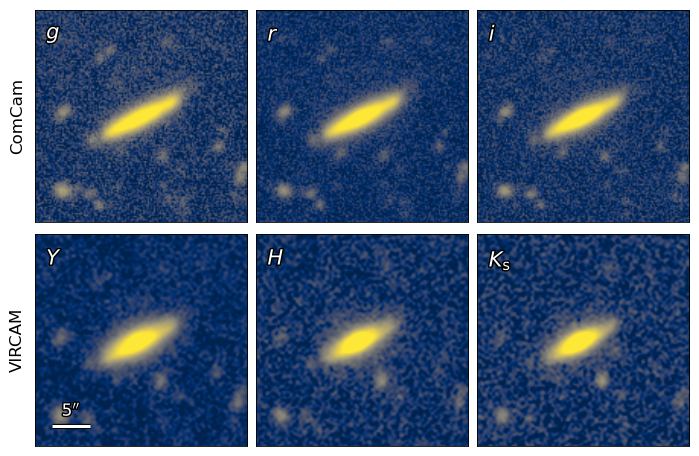


Saved PDF: data/image_products/selected_galaxy_morphology_6band.pdf
Displayed field: 28.0 arcsec
Native-resolution images; normalization measured from full cutouts.


In [19]:
# ============================================================
# Selected galaxy: 6-band morphology paper figure
#
# Top row:    ComCam g r i
# Bottom row: VIRCAM Y H Ks
#
# Native-resolution images
# Independent UDG-style stretch
# Zoomed to 28 arcsec
# ============================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from astropy.visualization import (
    ImageNormalize,
    AsinhStretch,
)


# ============================================================
# Configuration
# ============================================================

COMCAM_PLOT_BANDS = [
    "g",
    "r",
    "i",
]

VIRCAM_PLOT_BANDS = [
    "Y",
    "H",
    "K",
]

PLOT_BANDS = (
    COMCAM_PLOT_BANDS
    + VIRCAM_PLOT_BANDS
)


PANEL_LABELS_PLOT = {
    "g": r"$g$",
    "r": r"$r$",
    "i": r"$i$",
    "Y": r"$Y$",
    "H": r"$H$",
    "K": r"$K_{\rm s}$",
}


CMAP_NAME = "cividis"

PIXEL_SCALE_ARCSEC = 0.2

# 140 pixels = 28 arcsec
ZOOM_SIZE_PIX = 140

SCALE_BAR_ARCSEC = 5.0


OUTDIR = Path(
    "data/image_products"
)

OUTDIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_PDF = (
    OUTDIR
    / "selected_galaxy_morphology_6band.pdf"
)


# ============================================================
# Same display settings as the UDG figure
# ============================================================

DISPLAY_LOW_SIGMA = 1.0
DISPLAY_HIGH_PERCENTILE = 99.7
DISPLAY_ASINH_A = 0.04

DISPLAY_OVERRIDES = {}


# ============================================================
# Robust background scatter
# ============================================================

def robust_sigma(values):

    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        np.isfinite(values)
    ]

    if values.size == 0:
        return np.nan


    median = np.median(
        values
    )

    mad = np.median(
        np.abs(
            values - median
        )
    )


    return 1.4826 * mad


# ============================================================
# UDG-style independent normalization
# ============================================================

def display_normalization(
    array,
    band,
):

    finite = np.asarray(
        array,
        dtype=float,
    )

    finite = finite[
        np.isfinite(finite)
    ]


    if finite.size == 0:

        raise ValueError(
            f"No finite pixels are "
            f"available in band {band}."
        )


    median = np.median(
        finite
    )

    sigma = robust_sigma(
        finite
    )


    settings = {
        "low_sigma":
            DISPLAY_LOW_SIGMA,

        "high_percentile":
            DISPLAY_HIGH_PERCENTILE,

        "asinh_a":
            DISPLAY_ASINH_A,
    }


    settings.update(
        DISPLAY_OVERRIDES.get(
            band,
            {},
        )
    )


    if (
        not np.isfinite(sigma)
        or sigma <= 0
    ):

        sigma = np.std(
            finite
        )


    vmin = (
        median
        - settings["low_sigma"]
        * sigma
    )


    vmax = np.percentile(
        finite,
        settings[
            "high_percentile"
        ],
    )


    if (
        not np.isfinite(vmax)
        or vmax <= vmin
    ):

        vmax = (
            median
            + 10.0 * sigma
        )


    norm = ImageNormalize(
        vmin=vmin,
        vmax=vmax,
        stretch=AsinhStretch(
            a=settings[
                "asinh_a"
            ]
        ),
        clip=True,
    )


    return (
        norm,
        vmin,
        vmax,
    )


# ============================================================
# Centre crop
# ============================================================

def centre_crop(
    array,
    size_pix,
):

    array = np.asarray(
        array,
        dtype=float,
    )

    ny, nx = array.shape

    cx = nx // 2
    cy = ny // 2

    half = size_pix // 2

    x0 = cx - half
    y0 = cy - half

    x1 = x0 + size_pix
    y1 = y0 + size_pix


    return array[
        y0:y1,
        x0:x1,
    ]


# ============================================================
# Full native images
#
# Normalization is measured from these larger cutouts.
# ============================================================

full_plot_arrays = {
    band:
        np.asarray(
            selected_galaxy_full_images[
                band
            ],
            dtype=float,
        )
    for band in PLOT_BANDS
}


# ============================================================
# Zoomed images used only for display
# ============================================================

zoom_plot_arrays = {
    band:
        centre_crop(
            full_plot_arrays[
                band
            ],
            ZOOM_SIZE_PIX,
        )
    for band in PLOT_BANDS
}


# ============================================================
# Independent normalization from FULL cutouts
# ============================================================

plot_norms = {}


for band in PLOT_BANDS:

    norm, vmin, vmax = (
        display_normalization(
            full_plot_arrays[
                band
            ],
            band,
        )
    )

    plot_norms[
        band
    ] = norm


    print(
        f"{band:>2s}: "
        f"vmin={vmin:.5g}, "
        f"vmax={vmax:.5g}"
    )


# ============================================================
# Figure geometry
# ============================================================

fig_w = 7.4
fig_h = 4.6

fig = plt.figure(
    figsize=(
        fig_w,
        fig_h,
    )
)


label_left = 0.077

panel_left = 0.100
panel_right = 0.985

panel_gap_x = 0.012


panel_w = (
    panel_right
    - panel_left
    - 2 * panel_gap_x
) / 3.0


panel_h = (
    panel_w
    * fig_w
    / fig_h
)


row_gap_y = 0.025

bottom_y = 0.08

top_y = (
    bottom_y
    + panel_h
    + row_gap_y
)


axes = {}


# ============================================================
# Top row: ComCam
# ============================================================

for i, band in enumerate(
    COMCAM_PLOT_BANDS
):

    x0 = (
        panel_left
        + i
        * (
            panel_w
            + panel_gap_x
        )
    )


    axes[
        band
    ] = fig.add_axes(
        [
            x0,
            top_y,
            panel_w,
            panel_h,
        ]
    )


# ============================================================
# Bottom row: VIRCAM
# ============================================================

for i, band in enumerate(
    VIRCAM_PLOT_BANDS
):

    x0 = (
        panel_left
        + i
        * (
            panel_w
            + panel_gap_x
        )
    )


    axes[
        band
    ] = fig.add_axes(
        [
            x0,
            bottom_y,
            panel_w,
            panel_h,
        ]
    )


# ============================================================
# Draw panels
# ============================================================

for band in PLOT_BANDS:

    ax = axes[
        band
    ]

    image = zoom_plot_arrays[
        band
    ]

    ny, nx = image.shape


    ax.set_facecolor(
        plt.get_cmap(
            CMAP_NAME
        )(0.0)
    )


    ax.imshow(
        image,
        origin="lower",
        cmap=CMAP_NAME,
        norm=plot_norms[
            band
        ],
        interpolation="bilinear",
    )


    ax.set_xlim(
        -0.5,
        nx - 0.5,
    )

    ax.set_ylim(
        -0.5,
        ny - 0.5,
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )


    ax.text(
        0.055,
        0.93,
        PANEL_LABELS_PLOT[
            band
        ],
        transform=ax.transAxes,
        ha="left",
        va="top",
        color="white",
        fontsize=15,
        path_effects=[
            pe.withStroke(
                linewidth=2.1,
                foreground="black",
            )
        ],
    )


    ax.set_xticks([])
    ax.set_yticks([])


    for spine in (
        ax.spines.values()
    ):

        spine.set_linewidth(
            0.6
        )

        spine.set_color(
            "black"
        )


# ============================================================
# Row labels
# ============================================================

fig.text(
    label_left,
    top_y
    + 0.5 * panel_h,
    "ComCam",
    rotation=90,
    ha="center",
    va="center",
    fontsize=12,
)


fig.text(
    label_left,
    bottom_y
    + 0.5 * panel_h,
    "VIRCAM",
    rotation=90,
    ha="center",
    va="center",
    fontsize=12,
)


# ============================================================
# 5-arcsec scale bar on Y panel
# ============================================================

scale_axis = axes[
    "Y"
]


bar_length_pix = (
    SCALE_BAR_ARCSEC
    / PIXEL_SCALE_ARCSEC
)


ny, nx = (
    zoom_plot_arrays[
        "Y"
    ].shape
)


bar_x0 = (
    0.08 * nx
)

bar_y = (
    0.09 * ny
)

bar_x1 = (
    bar_x0
    + bar_length_pix
)


scale_axis.plot(
    [
        bar_x0,
        bar_x1,
    ],
    [
        bar_y,
        bar_y,
    ],
    color="white",
    linewidth=2.2,
    solid_capstyle="butt",
    path_effects=[
        pe.withStroke(
            linewidth=3.8,
            foreground="black",
        )
    ],
)


scale_axis.text(
    0.5
    * (
        bar_x0
        + bar_x1
    ),
    bar_y
    + 0.035 * ny,
    rf"{SCALE_BAR_ARCSEC:g}"
    r"$^{\prime\prime}$",
    ha="center",
    va="bottom",
    color="white",
    fontsize=12,
    path_effects=[
        pe.withStroke(
            linewidth=2.0,
            foreground="black",
        )
    ],
)


# ============================================================
# Save
# ============================================================

fig.savefig(
    OUTPUT_PDF,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.025,
)


plt.show()


print(
    "\nSaved PDF:",
    OUTPUT_PDF,
)

print(
    "Displayed field:",
    f"{ZOOM_SIZE_PIX * PIXEL_SCALE_ARCSEC:.1f} arcsec",
)

print(
    "Native-resolution images; "
    "normalization measured from full cutouts."
)


Display limits from full cutouts:

 g: vmin=-0.61068, vmax=38.511
 r: vmin=-0.86462, vmax=84.317
 i: vmin=-1.9199, vmax=123.25
 z: vmin=-4.16, vmax=155.87
 y: vmin=-26.552, vmax=180.4
 Z: vmin=-1.0846, vmax=37.774
 Y: vmin=-0.42784, vmax=44.837
 J: vmin=-1.0603, vmax=63.274
 H: vmin=-1.3573, vmax=88.764
 K: vmin=-2.1155, vmax=119.54


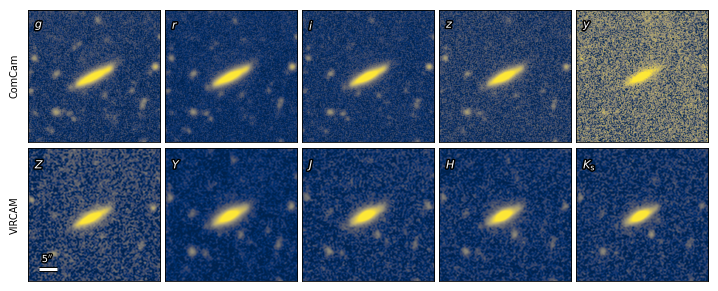


Saved PDF: data/image_products/selected_galaxy_morphology_10band.pdf
Displayed field: 36.0 arcsec
Bands: g r i z y Z Y J H K
Each band has an independent display normalization.


In [20]:
# ============================================================
# Selected galaxy: 10-band morphology figure
#
# Top row:    ComCam g r i z y
# Bottom row: VIRCAM Z Y J H Ks
#
# Only u is omitted.
#
# - Native-resolution images
# - Independent stretch for every band
# - Normalization measured from the full cutouts
# - 28 arcsec displayed field
# - No PSF matching
# - No scientific smoothing
# ============================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from astropy.visualization import (
    ImageNormalize,
    AsinhStretch,
)


# ============================================================
# Configuration
# ============================================================

COMCAM_PLOT_BANDS = [
    "g",
    "r",
    "i",
    "z",
    "y",
]

VIRCAM_PLOT_BANDS = [
    "Z",
    "Y",
    "J",
    "H",
    "K",
]

PLOT_BANDS = (
    COMCAM_PLOT_BANDS
    + VIRCAM_PLOT_BANDS
)


PANEL_LABELS = {
    "g": r"$g$",
    "r": r"$r$",
    "i": r"$i$",
    "z": r"$z$",
    "y": r"$y$",
    "Z": r"$Z$",
    "Y": r"$Y$",
    "J": r"$J$",
    "H": r"$H$",
    "K": r"$K_{\rm s}$",
}


CMAP_NAME = "cividis"

PIXEL_SCALE_ARCSEC = 0.2

# 180 pixels = 36 arcsec
ZOOM_SIZE_PIX = 180

SCALE_BAR_ARCSEC = 5.0


OUTDIR = Path(
    "data/image_products"
)

OUTDIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_PDF = (
    OUTDIR
    / "selected_galaxy_morphology_10band.pdf"
)


# ============================================================
# Display settings
#
# Same basic normalization used for the UDG figure.
# Each band is normalized independently.
# ============================================================

DISPLAY_LOW_SIGMA = 1.0
DISPLAY_HIGH_PERCENTILE = 99.7
DISPLAY_ASINH_A = 0.04

DISPLAY_OVERRIDES = {}


# ============================================================
# Robust background scatter
# ============================================================

def robust_sigma(values):

    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        np.isfinite(values)
    ]

    if values.size == 0:
        return np.nan

    median = np.median(
        values
    )

    mad = np.median(
        np.abs(
            values - median
        )
    )

    return 1.4826 * mad


# ============================================================
# Independent display normalization
# ============================================================

def display_normalization(
    array,
    band,
):

    finite = np.asarray(
        array,
        dtype=float,
    )

    finite = finite[
        np.isfinite(finite)
    ]

    if finite.size == 0:

        raise ValueError(
            f"No finite pixels are "
            f"available in band {band}."
        )


    median = np.median(
        finite
    )

    sigma = robust_sigma(
        finite
    )


    settings = {
        "low_sigma":
            DISPLAY_LOW_SIGMA,

        "high_percentile":
            DISPLAY_HIGH_PERCENTILE,

        "asinh_a":
            DISPLAY_ASINH_A,
    }

    settings.update(
        DISPLAY_OVERRIDES.get(
            band,
            {},
        )
    )


    if (
        not np.isfinite(sigma)
        or sigma <= 0
    ):

        sigma = np.std(
            finite
        )


    vmin = (
        median
        - settings["low_sigma"]
        * sigma
    )

    vmax = np.percentile(
        finite,
        settings[
            "high_percentile"
        ],
    )


    if (
        not np.isfinite(vmax)
        or vmax <= vmin
    ):

        vmax = (
            median
            + 10.0 * sigma
        )


    norm = ImageNormalize(
        vmin=vmin,
        vmax=vmax,
        stretch=AsinhStretch(
            a=settings[
                "asinh_a"
            ]
        ),
        clip=True,
    )


    return norm, vmin, vmax


# ============================================================
# Centre crop
# ============================================================

def centre_crop(
    array,
    size_pix,
):

    array = np.asarray(
        array,
        dtype=float,
    )

    ny, nx = array.shape

    cx = nx // 2
    cy = ny // 2

    half = size_pix // 2

    x0 = cx - half
    y0 = cy - half

    x1 = x0 + size_pix
    y1 = y0 + size_pix


    return array[
        y0:y1,
        x0:x1,
    ]


# ============================================================
# Full native cutouts
#
# IMPORTANT:
# these full images determine the normalization.
# ============================================================

full_plot_arrays = {
    band: np.asarray(
        selected_galaxy_full_images[
            band
        ],
        dtype=float,
    )
    for band in PLOT_BANDS
}


# ============================================================
# Zoomed cutouts
#
# Used only for display.
# ============================================================

zoom_plot_arrays = {
    band: centre_crop(
        full_plot_arrays[
            band
        ],
        ZOOM_SIZE_PIX,
    )
    for band in PLOT_BANDS
}


# ============================================================
# Independent normalization from FULL images
# ============================================================

plot_norms = {}


print(
    "Display limits from full cutouts:\n"
)


for band in PLOT_BANDS:

    norm, vmin, vmax = (
        display_normalization(
            full_plot_arrays[
                band
            ],
            band,
        )
    )

    plot_norms[
        band
    ] = norm


    print(
        f"{band:>2s}: "
        f"vmin={vmin:.5g}, "
        f"vmax={vmax:.5g}"
    )


# ============================================================
# Figure geometry
# ============================================================

fig_w = 7.4
fig_h = 3.35


fig = plt.figure(
    figsize=(
        fig_w,
        fig_h,
    )
)


# Row labels kept close to panels
label_left = 0.053

panel_left = 0.070
panel_right = 0.990

panel_gap_x = 0.006


# Five panels per row
panel_w = (
    panel_right
    - panel_left
    - 4 * panel_gap_x
) / 5.0


# Keep panels square
panel_h = (
    panel_w
    * fig_w
    / fig_h
)


row_gap_y = 0.018

bottom_y = 0.070

top_y = (
    bottom_y
    + panel_h
    + row_gap_y
)


axes = {}


# ============================================================
# Top row: ComCam
# ============================================================

for i, band in enumerate(
    COMCAM_PLOT_BANDS
):

    x0 = (
        panel_left
        + i
        * (
            panel_w
            + panel_gap_x
        )
    )

    axes[
        band
    ] = fig.add_axes(
        [
            x0,
            top_y,
            panel_w,
            panel_h,
        ]
    )


# ============================================================
# Bottom row: VIRCAM
# ============================================================

for i, band in enumerate(
    VIRCAM_PLOT_BANDS
):

    x0 = (
        panel_left
        + i
        * (
            panel_w
            + panel_gap_x
        )
    )

    axes[
        band
    ] = fig.add_axes(
        [
            x0,
            bottom_y,
            panel_w,
            panel_h,
        ]
    )


# ============================================================
# Draw all 10 panels
# ============================================================

for band in PLOT_BANDS:

    ax = axes[
        band
    ]

    image = zoom_plot_arrays[
        band
    ]

    ny, nx = image.shape


    ax.set_facecolor(
        plt.get_cmap(
            CMAP_NAME
        )(0.0)
    )


    ax.imshow(
        image,
        origin="lower",
        cmap=CMAP_NAME,
        norm=plot_norms[
            band
        ],

        # Display interpolation only.
        # Underlying images are unchanged.
        interpolation="bilinear",
    )


    ax.set_xlim(
        -0.5,
        nx - 0.5,
    )

    ax.set_ylim(
        -0.5,
        ny - 0.5,
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )


    # --------------------------------------------------------
    # Band label
    # --------------------------------------------------------

    ax.text(
        0.055,
        0.925,
        PANEL_LABELS[
            band
        ],
        transform=ax.transAxes,
        ha="left",
        va="top",
        color="white",
        fontsize=8,
        path_effects=[
            pe.withStroke(
                linewidth=2.2,
                foreground="black",
            )
        ],
    )


    ax.set_xticks([])
    ax.set_yticks([])


    for spine in (
        ax.spines.values()
    ):

        spine.set_linewidth(
            0.6
        )

        spine.set_color(
            "black"
        )


# ============================================================
# Row labels
# ============================================================

fig.text(
    label_left,
    top_y
    + 0.5 * panel_h,
    "ComCam",
    rotation=90,
    ha="center",
    va="center",
    fontsize=7,
)


fig.text(
    label_left,
    bottom_y
    + 0.5 * panel_h,
    "VIRCAM",
    rotation=90,
    ha="center",
    va="center",
    fontsize=7,
)


# ============================================================
# 5 arcsec scale bar
#
# Put on first VIRCAM panel.
# ============================================================

scale_axis = axes[
    "Z"
]


bar_length_pix = (
    SCALE_BAR_ARCSEC
    / PIXEL_SCALE_ARCSEC
)


ny, nx = (
    zoom_plot_arrays[
        "Z"
    ].shape
)


bar_x0 = (
    0.08 * nx
)

bar_y = (
    0.09 * ny
)

bar_x1 = (
    bar_x0
    + bar_length_pix
)


scale_axis.plot(
    [
        bar_x0,
        bar_x1,
    ],
    [
        bar_y,
        bar_y,
    ],
    color="white",
    linewidth=2.2,
    solid_capstyle="butt",
    path_effects=[
        pe.withStroke(
            linewidth=3.8,
            foreground="black",
        )
    ],
)


scale_axis.text(
    0.5
    * (
        bar_x0
        + bar_x1
    ),
    bar_y
    + 0.035 * ny,
    rf"{SCALE_BAR_ARCSEC:g}"
    r"$^{\prime\prime}$",
    ha="center",
    va="bottom",
    color="white",
    fontsize=7,
    path_effects=[
        pe.withStroke(
            linewidth=2.0,
            foreground="black",
        )
    ],
)


# ============================================================
# Save
# ============================================================

fig.savefig(
    OUTPUT_PDF,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.025,
)


plt.show()


print(
    "\nSaved PDF:",
    OUTPUT_PDF,
)

print(
    "Displayed field:",
    f"{ZOOM_SIZE_PIX * PIXEL_SCALE_ARCSEC:.1f} arcsec",
)

print(
    "Bands:",
    " ".join(
        PLOT_BANDS
    ),
)

print(
    "Each band has an independent display normalization."
)
